In [1]:
# CELL 1 — Imports & Paths

import os, json, math, glob
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

BASE_DIR = Path("../../data")
OUT_SUMMARY_DIR = BASE_DIR / "summary"
OUT_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR.resolve())
print("OUT_SUMMARY_DIR:", OUT_SUMMARY_DIR.resolve())

BASE_DIR: /app/data
OUT_SUMMARY_DIR: /app/data/summary


In [2]:
# CELL 2 — Load summaries (auto-discover) + Core builders

def discover_summary_files(base_dir: Path) -> List[Path]:
    """
    Discover summary JSON files robustly.
    Supports:
      ../data/Book1/summary.json
      ../data/Book1/*_summary.json
      ../data/**/summary.json
      ../data/**/*_summary.json
    """
    patterns = [
        str(base_dir / "Book*" / "summary.json"),
        str(base_dir / "Book*" / "*_summary.json"),
        str(base_dir / "**" / "summary.json"),
        str(base_dir / "**" / "*_summary.json"),
    ]
    files = []
    for pat in patterns:
        files.extend([Path(p) for p in glob.glob(pat, recursive=True)])
    # de-dupe + keep only json files
    files = sorted(set([f for f in files if f.suffix.lower() == ".json" and f.exists()]))
    return files

def infer_book_name(summary_path: Path, summary_obj: Dict[str, Any]) -> str:
    # Prefer folder name like Book1/Book2; fallback to pdf filename stem
    parent = summary_path.parent.name
    if parent.lower().startswith("book"):
        return parent
    pdf_path = (summary_obj.get("document", {}) or {}).get("pdf_path", "")
    if pdf_path:
        return Path(pdf_path).stem[:20]
    return summary_path.stem.replace("_summary", "")

def load_summaries(base_dir: Path) -> Dict[str, Dict[str, Any]]:
    files = discover_summary_files(base_dir)
    summaries = {}
    for fp in files:
        try:
            obj = json.loads(fp.read_text(encoding="utf-8"))
            book = infer_book_name(fp, obj)
            # if collision, suffix
            if book in summaries:
                k = 2
                while f"{book}_{k}" in summaries:
                    k += 1
                book = f"{book}_{k}"
            obj["_source_path"] = str(fp)
            summaries[book] = obj
        except Exception as e:
            print(f"WARNING: failed to load {fp}: {e}")
    return summaries

def build_sections_df(summaries: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for book, s in summaries.items():
        doc = s.get("document", {}) or {}
        hier = s.get("hierarchy", {}) or {}
        secs = s.get("sections", []) or []
        for n in secs:
            rows.append({
                "book": book,
                "source_path": s.get("_source_path"),
                "pdf_path": doc.get("pdf_path"),
                "extractor": doc.get("extractor"),
                "num_pages": doc.get("num_pages"),
                "toc_pages": doc.get("toc_pages"),
                "max_depth": hier.get("max_depth"),
                "avg_depth": hier.get("avg_depth"),
                "num_headings_from_toc": hier.get("num_headings_from_toc"),
                "depth_distribution": hier.get("depth_distribution"),
                # node fields
                "node_id": n.get("node_id"),
                "section_id": n.get("section_id"),
                "title": n.get("title"),
                "level": n.get("level"),
                "parent_node_id": n.get("parent_node_id"),
                "start_page": n.get("start_page"),
                "end_page": n.get("end_page"),
                "line_count": n.get("line_count", 0),
                "char_count": n.get("char_count", 0),
                "word_count": n.get("word_count", 0),
                "token_count": n.get("token_count", 0),
                "table_count": n.get("table_count", 0),
                "figure_count": n.get("figure_count", 0),
            })
    df = pd.DataFrame(rows)
    # numeric hygiene
    for c in ["num_pages","max_depth","avg_depth","num_headings_from_toc","level","start_page","end_page",
              "line_count","char_count","word_count","token_count","table_count","figure_count"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def compute_leaf_nodes(df_sections: pd.DataFrame) -> pd.DataFrame:
    """
    Leaf = node_id that is never referenced as parent_node_id within the same book.
    """
    df = df_sections.copy()
    df["node_id"] = df["node_id"].astype(str)
    df["parent_node_id"] = df["parent_node_id"].astype("string")

    # For each book, compute set of parents that appear
    parent_sets = df.groupby("book")["parent_node_id"].apply(lambda x: set([p for p in x.dropna().tolist()]))
    # mark leaf
    def is_leaf(row):
        parents = parent_sets.get(row["book"], set())
        return row["node_id"] not in parents
    df["is_leaf"] = df.apply(is_leaf, axis=1)
    return df

summaries = load_summaries(BASE_DIR)
print("Loaded books:", list(summaries.keys()))
df_sections_all = build_sections_df(summaries)
df_sections_all = compute_leaf_nodes(df_sections_all)

display(df_sections_all.head(10))
print("Total nodes:", len(df_sections_all), "| leaf nodes:", int(df_sections_all["is_leaf"].sum()))

Loaded books: ['Book1', 'Book2', 'Book3', 'Book4']


,book,source_path,pdf_path,extractor,num_pages,toc_pages,max_depth,avg_depth,num_headings_from_toc,depth_distribution,...,parent_node_id,start_page,end_page,line_count,char_count,word_count,token_count,table_count,figure_count,is_leaf
0,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,<NA>,9,33,664,29429,4561,4530,0,0,False
1,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T1:Part I,10,11,52,3028,449,452,0,0,False
2,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T2:1,10,10,8,503,72,71,0,0,True
3,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T2:1,10,11,23,1253,196,203,0,0,True
4,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T2:1,11,11,4,268,42,41,0,0,True
5,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T2:1,11,11,3,208,28,28,0,0,True
6,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T1:Part I,12,14,92,4530,606,597,0,0,True
7,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T1:Part I,15,22,240,11830,1830,1826,0,0,True
8,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T1:Part I,23,33,275,9940,1663,1642,0,0,False
9,Book1,../../data/Book1/summary.json,../data/raw/EMV_v4.4_Book_1_ICC_to_Terminal_In...,pdfplumber,81,"[4, 6]",4,3.074627,67,"{'1': 5, '2': 11, '3': 25, '4': 26}",...,T9:4,23,29,181,5162,787,760,0,0,True


Total nodes: 468 | leaf nodes: 344


,book,num_pages,max_depth,avg_depth,num_headings_from_toc,num_nodes,num_leaf_nodes
0,Book1,81,4,3.074627,67,67,47
1,Book2,192,4,3.152672,131,131,93
2,Book3,230,4,3.119205,151,151,112
3,Book4,133,4,3.142857,119,119,92


Saved: ../../data/summary/books_overview.csv


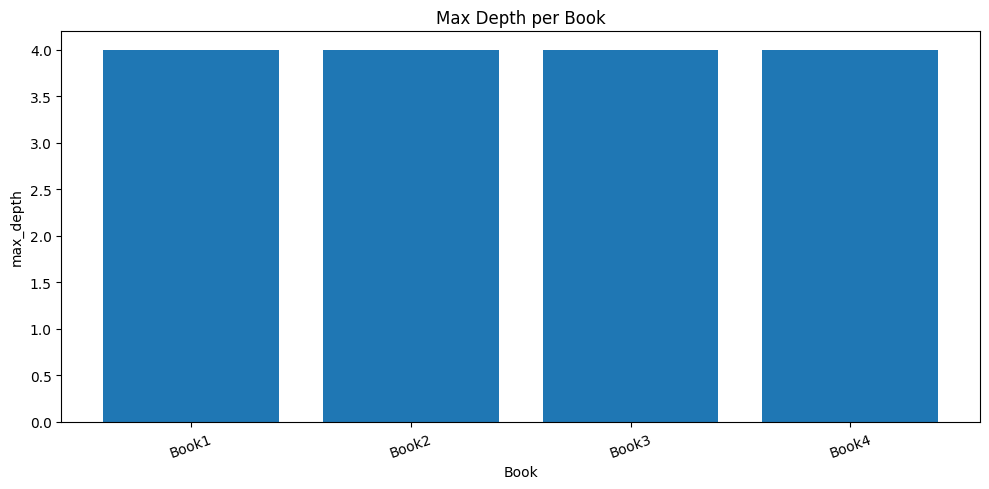

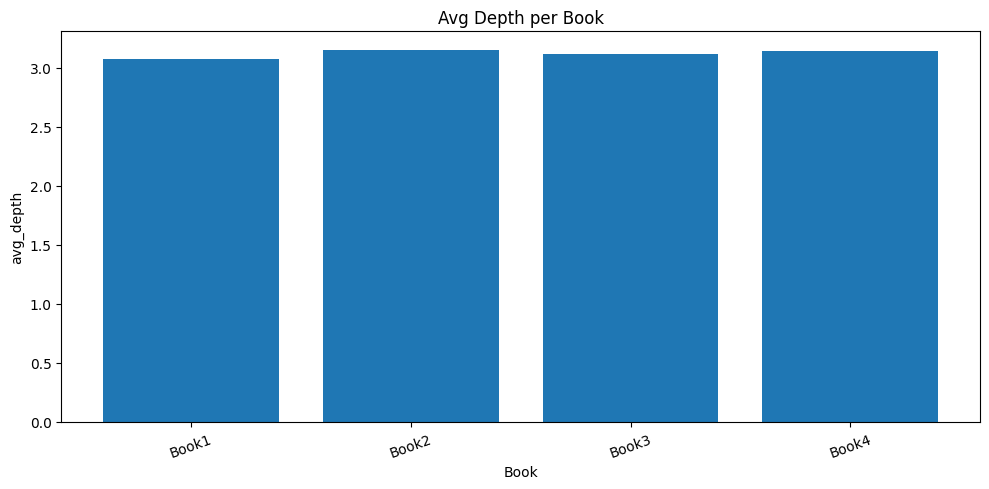

In [3]:
# CELL 3 — STEP 1: Structural complexity per book + depth distributions + plots

def books_overview(df: pd.DataFrame) -> pd.DataFrame:
    # book-level metadata from first row per book (no node summing)
    g = df.groupby("book", dropna=False)
    out = g.agg(
        num_pages=("num_pages", "max"),
        max_depth=("max_depth", "max"),
        avg_depth=("avg_depth", "max"),
        num_headings_from_toc=("num_headings_from_toc", "max"),
        num_nodes=("node_id", "count"),
        num_leaf_nodes=("is_leaf", "sum"),
    ).reset_index()
    return out.sort_values("book")

df_books = books_overview(df_sections_all)
display(df_books)

# Save overview
(df_books).to_csv(OUT_SUMMARY_DIR / "books_overview.csv", index=False)
print("Saved:", OUT_SUMMARY_DIR / "books_overview.csv")

# Plot max_depth per book
plt.figure()
plt.bar(df_books["book"], df_books["max_depth"])
plt.title("Max Depth per Book")
plt.xlabel("Book")
plt.ylabel("max_depth")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Plot avg_depth per book
plt.figure()
plt.bar(df_books["book"], df_books["avg_depth"])
plt.title("Avg Depth per Book")
plt.xlabel("Book")
plt.ylabel("avg_depth")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


depth_level,book,1,2,3,4
0,Book1,5,11,25,26
1,Book2,4,20,59,48
2,Book3,5,24,70,52
3,Book4,5,17,53,44


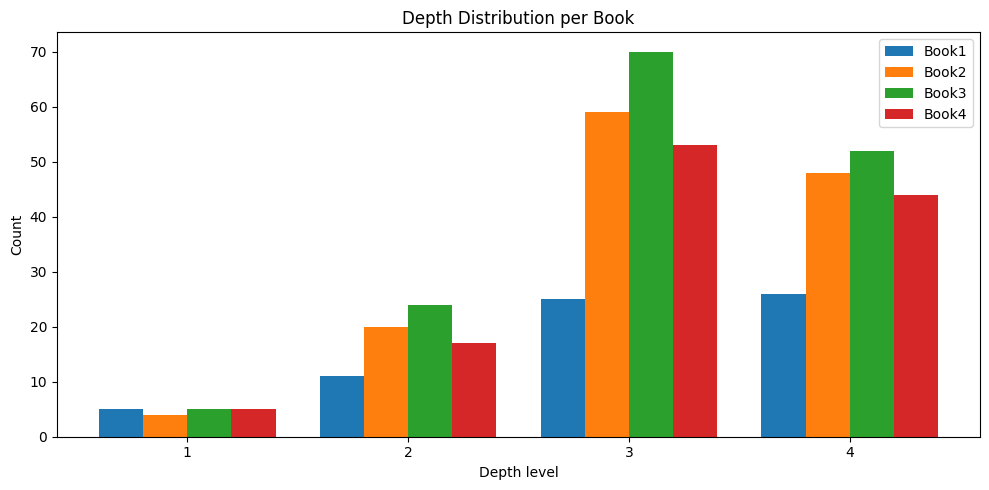

In [14]:

# Expand depth_distribution and plot same bins across books
def depth_distribution_df(summaries: Dict[str, Dict[str, Any]]) -> pd.DataFrame:
    rows = []
    all_levels = set()
    for book, s in summaries.items():
        dd = (s.get("hierarchy", {}) or {}).get("depth_distribution", {}) or {}
        # keys may be strings
        for k, v in dd.items():
            try:
                lvl = int(k)
            except:
                continue
            all_levels.add(lvl)
            rows.append({"book": book, "depth_level": lvl, "count": int(v)})
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    # fill missing levels per book
    levels = sorted(all_levels)
    out = (df.pivot_table(index="book", columns="depth_level", values="count", aggfunc="sum")
             .reindex(columns=levels)
             .fillna(0)
             .astype(int))
    out = out.reset_index()
    return out

df_depth = depth_distribution_df(summaries)
display(df_depth)

# Plot depth histograms (same bins) per book
if not df_depth.empty:
    depth_cols = [c for c in df_depth.columns if c != "book"]
    x = np.arange(len(depth_cols))
    width = 0.8 / max(1, len(df_depth))
    plt.figure()
    for i, (_, r) in enumerate(df_depth.iterrows()):
        plt.bar(x + i*width, [r[c] for c in depth_cols], width=width, label=r["book"])
    plt.title("Depth Distribution per Book")
    plt.xlabel("Depth level")
    plt.ylabel("Count")
    plt.xticks(x + width*(len(df_depth)-1)/2, depth_cols)
    plt.legend()
    plt.tight_layout()
    plt.show()

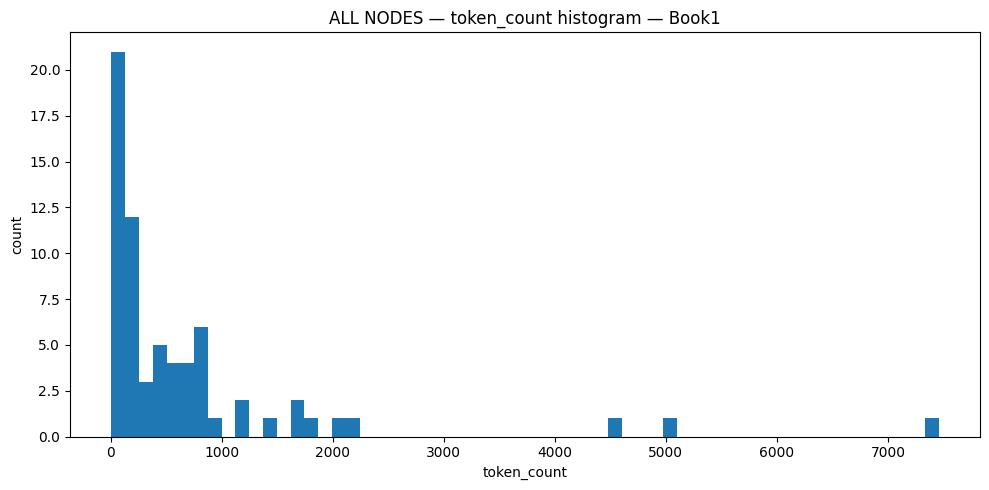

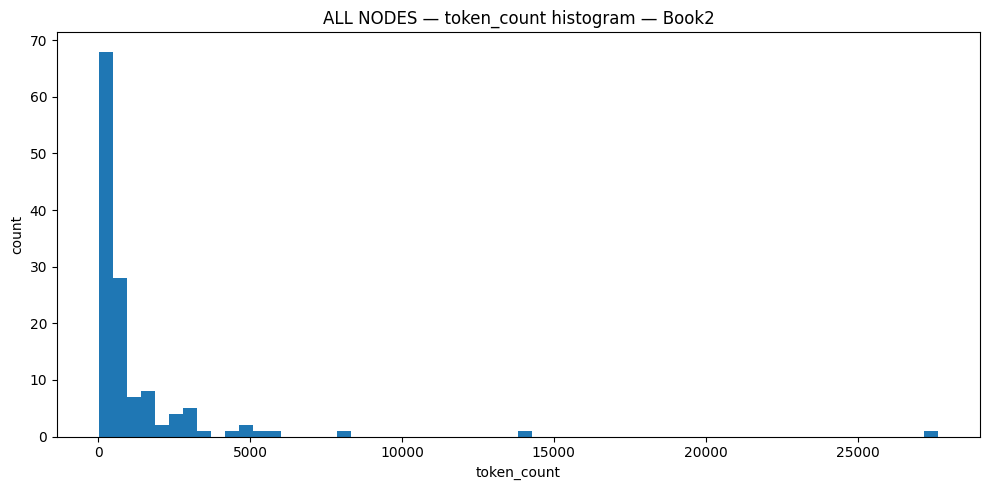

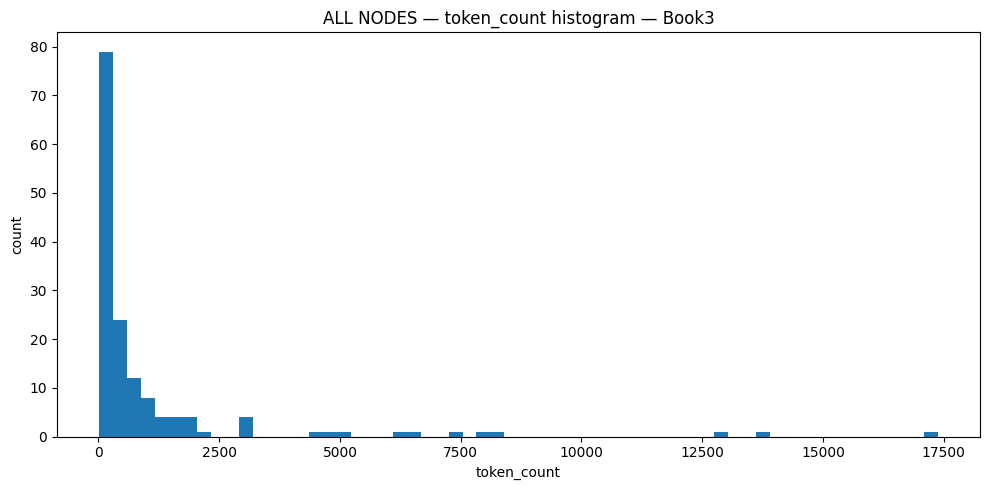

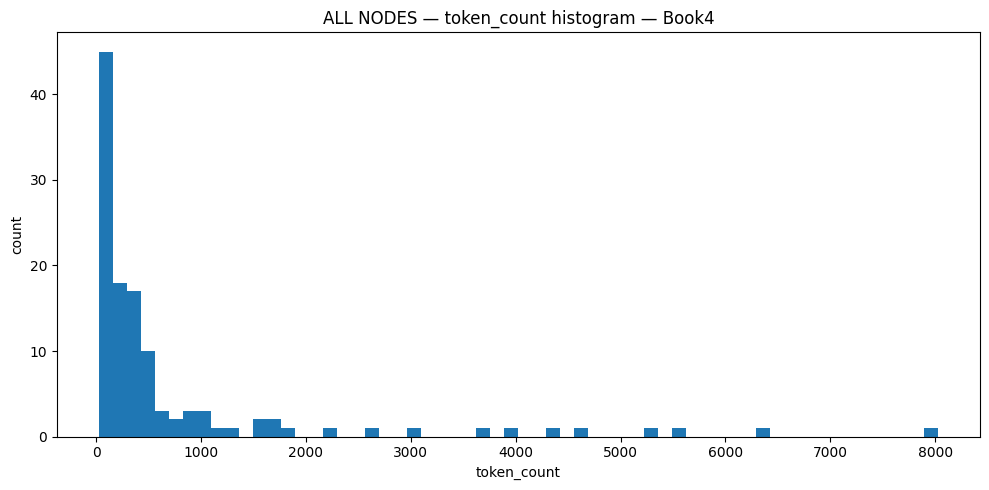

/tmp/ipykernel_107/169973180.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=books, showfliers=True)


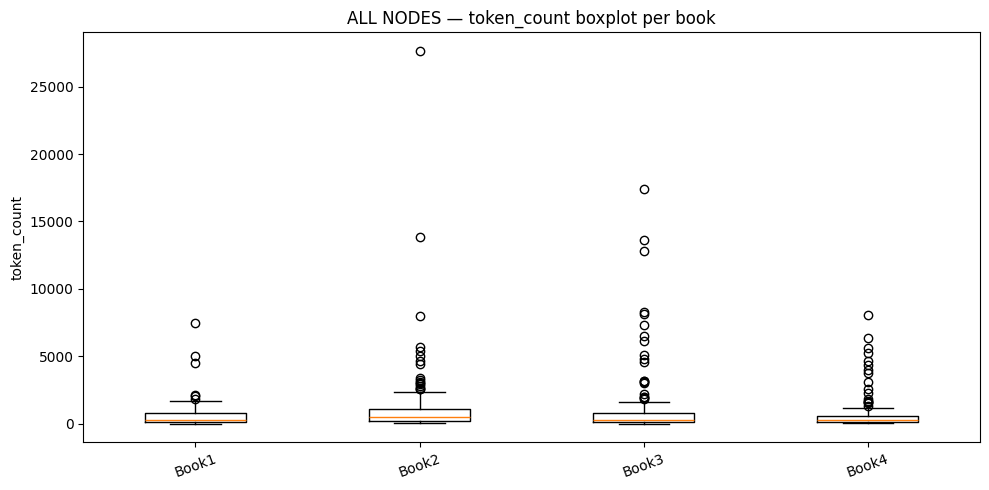

,book,pct_sections_gt_512,pct_sections_gt_1000,pct_sections_lt_200,n_nodes
0,Book1,0.388060,0.164179,0.432836,67
1,Book2,0.450382,0.259542,0.297710,131
2,Book3,0.331126,0.218543,0.390728,151
3,Book4,0.285714,0.168067,0.428571,119


,book,level,n,avg_tokens,med_tokens,avg_words,med_words
0,Book1,1,5,3012.800000,2151.0,3020.400000,2191.0
1,Book1,2,11,1346.909091,789.0,1350.272727,811.0
2,Book1,3,25,480.240000,288.0,480.240000,281.0
3,Book1,4,26,217.461538,124.5,213.538462,128.5
4,Book2,1,4,12190.500000,9155.0,12217.750000,9129.0
5,Book2,2,20,2424.950000,1881.0,2430.450000,1796.5
6,Book2,3,59,719.610169,408.0,719.644068,410.0
7,Book2,4,48,449.312500,387.0,449.270833,396.5
8,Book3,1,5,10242.600000,8322.0,10262.800000,8388.0
9,Book3,2,24,2121.125000,1177.0,2125.333333,1184.5


In [5]:
# CELL 4 — STEP 2: Section size distribution (token/word) using all nodes

def plot_hist_per_book(df: pd.DataFrame, value_col: str, bins: int = 50, title_prefix: str = ""):
    books = sorted(df["book"].unique())
    for b in books:
        d = df[df["book"] == b][value_col].dropna().astype(float)
        if d.empty:
            continue
        plt.figure()
        plt.hist(d, bins=bins)
        plt.title(f"{title_prefix}{value_col} histogram — {b}")
        plt.xlabel(value_col)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

def plot_boxplot_per_book(df: pd.DataFrame, value_col: str, title: str):
    books = sorted(df["book"].unique())
    data = [df[df["book"] == b][value_col].dropna().astype(float).values for b in books]
    plt.figure()
    plt.boxplot(data, labels=books, showfliers=True)
    plt.title(title)
    plt.ylabel(value_col)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# Histograms and boxplots (all nodes)
plot_hist_per_book(df_sections_all, "token_count", bins=60, title_prefix="ALL NODES — ")
plot_boxplot_per_book(df_sections_all, "token_count", "ALL NODES — token_count boxplot per book")

# Percentages per book: >512, >1000, <200 (all nodes)
def pct(x: pd.Series) -> float:
    if len(x) == 0:
        return float("nan")
    return float(x.mean())

pct_rows = []
for b, g in df_sections_all.groupby("book"):
    tokens = g["token_count"].fillna(0).astype(float)
    pct_rows.append({
        "book": b,
        "pct_sections_gt_512": pct(tokens > 512),
        "pct_sections_gt_1000": pct(tokens > 1000),
        "pct_sections_lt_200": pct(tokens < 200),
        "n_nodes": int(len(g)),
    })
df_pct = pd.DataFrame(pct_rows).sort_values("book")
display(df_pct)

# Word/token vs hierarchy level (grouped by level, all nodes)
lvl_stats = (df_sections_all.groupby(["book","level"], dropna=False)
             .agg(
                 n=("node_id","count"),
                 avg_tokens=("token_count","mean"),
                 med_tokens=("token_count","median"),
                 avg_words=("word_count","mean"),
                 med_words=("word_count","median"),
             )
             .reset_index()
             .sort_values(["book","level"]))
display(lvl_stats.head(50))

In [6]:
# CELL 5 — STEP 3: Word count by hierarchy level tables (all nodes vs leaf-only)

def level_metrics_table(df: pd.DataFrame, leaf_only: bool) -> pd.DataFrame:
    d = df[df["is_leaf"]].copy() if leaf_only else df.copy()
    d["token_count"] = d["token_count"].fillna(0).astype(float)
    d["word_count"] = d["word_count"].fillna(0).astype(float)
    tbl = (d.groupby(["book","level"], dropna=False)
           .agg(
               n=("node_id","count"),
               avg_word=("word_count","mean"),
               max_word=("word_count","max"),
               pct_gt_1000_tokens=("token_count", lambda x: float((x > 1000).mean()) if len(x) else float("nan")),
               avg_tokens=("token_count","mean"),
               max_tokens=("token_count","max"),
           )
           .reset_index()
           .sort_values(["book","level"]))
    tbl["leaf_only"] = leaf_only
    return tbl

df_level_all = level_metrics_table(df_sections_all, leaf_only=False)
df_level_leaf = level_metrics_table(df_sections_all, leaf_only=True)

def print_red(text):
    print(f"\033[1;91m{text}\033[0m")
print_red("leaf_only false")
display(df_level_all.head(40))
print_red("leaf_only true")
display(df_level_leaf.head(40))

df_level_all_books = pd.concat([df_level_all, df_level_leaf], ignore_index=True)
df_level_all_books.to_csv(OUT_SUMMARY_DIR / "level_metrics_all_books.csv", index=False)
print("Saved:", OUT_SUMMARY_DIR / "level_metrics_all_books.csv")

leaf_only false


,book,level,n,avg_word,max_word,pct_gt_1000_tokens,avg_tokens,max_tokens,leaf_only
0,Book1,1,5,3020.400000,7539.0,0.600000,3012.800000,7455.0,False
1,Book1,2,11,1350.272727,5045.0,0.454545,1346.909091,5007.0,False
2,Book1,3,25,480.240000,2104.0,0.120000,480.240000,2090.0,False
3,Book1,4,26,213.538462,842.0,0.000000,217.461538,833.0,False
4,Book2,1,4,12217.750000,27967.0,1.000000,12190.500000,27652.0,False
5,Book2,2,20,2430.450000,7982.0,0.650000,2424.950000,8019.0,False
6,Book2,3,59,719.644068,4690.0,0.254237,719.610169,4674.0,False
7,Book2,4,48,449.270833,2512.0,0.041667,449.312500,2574.0,False
8,Book3,1,5,10262.800000,17341.0,1.000000,10242.600000,17382.0,False
9,Book3,2,24,2125.333333,13579.0,0.583333,2121.125000,13619.0,False


leaf_only true


,book,level,n,avg_word,max_word,pct_gt_1000_tokens,avg_tokens,max_tokens,leaf_only
0,Book1,1,1,19.000000,19.0,0.000000,18.000000,18.0,True
1,Book1,2,3,816.333333,1830.0,0.333333,811.666667,1826.0,True
2,Book1,3,17,340.529412,1256.0,0.058824,338.352941,1222.0,True
3,Book1,4,26,213.538462,842.0,0.000000,217.461538,833.0,True
4,Book2,2,4,645.500000,1830.0,0.250000,641.750000,1826.0,True
5,Book2,3,41,411.000000,1454.0,0.121951,411.463415,1503.0,True
6,Book2,4,48,449.270833,2512.0,0.041667,449.312500,2574.0,True
7,Book3,2,6,711.333333,1833.0,0.333333,751.833333,1829.0,True
8,Book3,3,54,446.814815,6163.0,0.092593,448.259259,6158.0,True
9,Book3,4,52,351.346154,3057.0,0.057692,346.730769,3030.0,True


Saved: ../../data/summary/level_metrics_all_books.csv


In [7]:
# # CELL 6 — STEP 4 & 5: Table + Figure density analysis (NO DOUBLE COUNTING for book totals => leaf-only)

# def leaf_book_totals(df: pd.DataFrame) -> pd.DataFrame:
#     d = df[df["is_leaf"]].copy()
#     out = (d.groupby("book")
#            .agg(
#                n_leaf=("node_id","count"),
#                total_leaf_tokens=("token_count","sum"),
#                total_leaf_words=("word_count","sum"),
#                total_leaf_tables=("table_count","sum"),
#                total_leaf_figures=("figure_count","sum"),
#                avg_leaf_tokens=("token_count","mean"),
#            )
#            .reset_index()
#            .sort_values("book"))
#     return out

# df_leaf_totals = leaf_book_totals(df_sections_all)
# display(df_leaf_totals)

# # Table_count per section distribution (all nodes)
# plot_hist_per_book(df_sections_all, "table_count", bins=40, title_prefix="ALL NODES — ")
# # Scatter token_count vs table_count (all nodes)
# for b, g in df_sections_all.groupby("book"):
#     x = g["token_count"].fillna(0).astype(float)
#     y = g["table_count"].fillna(0).astype(float)
#     plt.figure()
#     plt.scatter(x, y, s=12)
#     plt.title(f"token_count vs table_count — {b} (all nodes)")
#     plt.xlabel("token_count")
#     plt.ylabel("table_count")
#     plt.tight_layout()
#     plt.show()

# # Figure_count per section distribution (all nodes)
# plot_hist_per_book(df_sections_all, "figure_count", bins=40, title_prefix="ALL NODES — ")
# # Scatter token_count vs figure_count (all nodes)
# for b, g in df_sections_all.groupby("book"):
#     x = g["token_count"].fillna(0).astype(float)
#     y = g["figure_count"].fillna(0).astype(float)
#     plt.figure()
#     plt.scatter(x, y, s=12)
#     plt.title(f"token_count vs figure_count — {b} (all nodes)")
#     plt.xlabel("token_count")
#     plt.ylabel("figure_count")
#     plt.tight_layout()
#     plt.show()

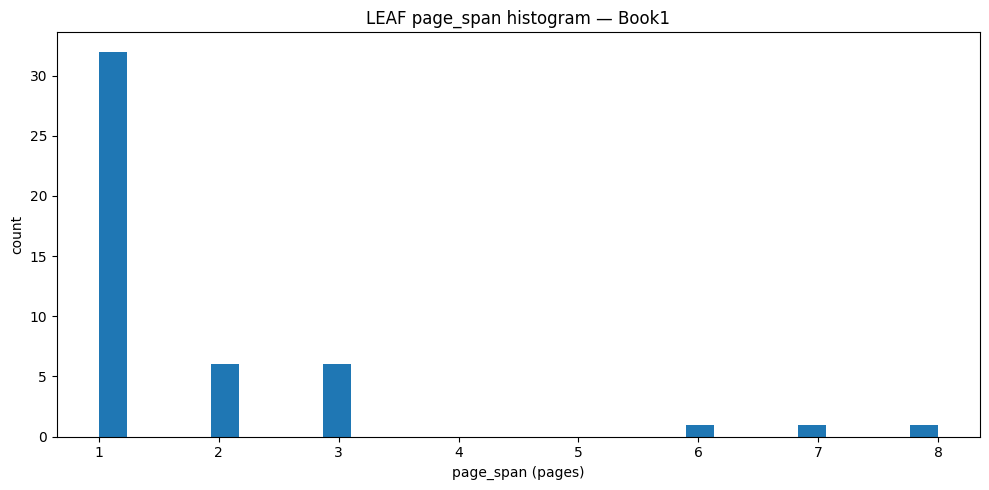

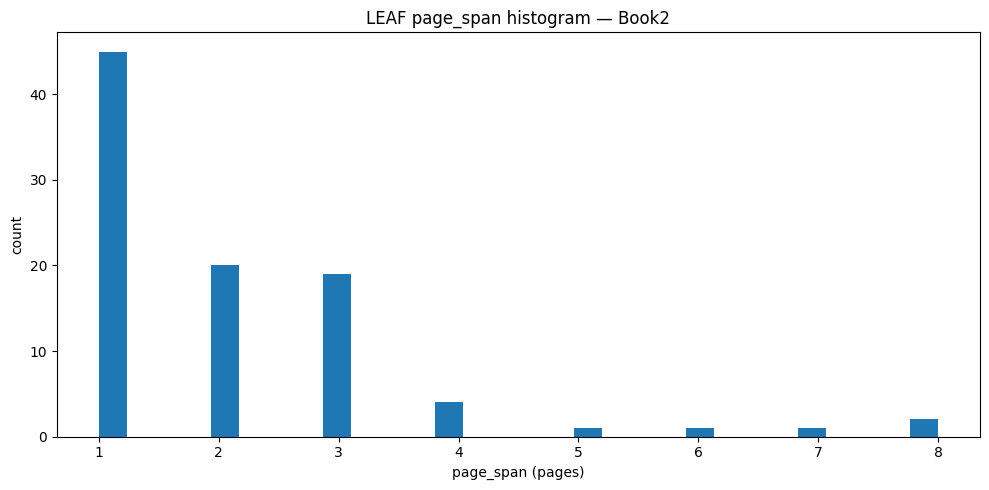

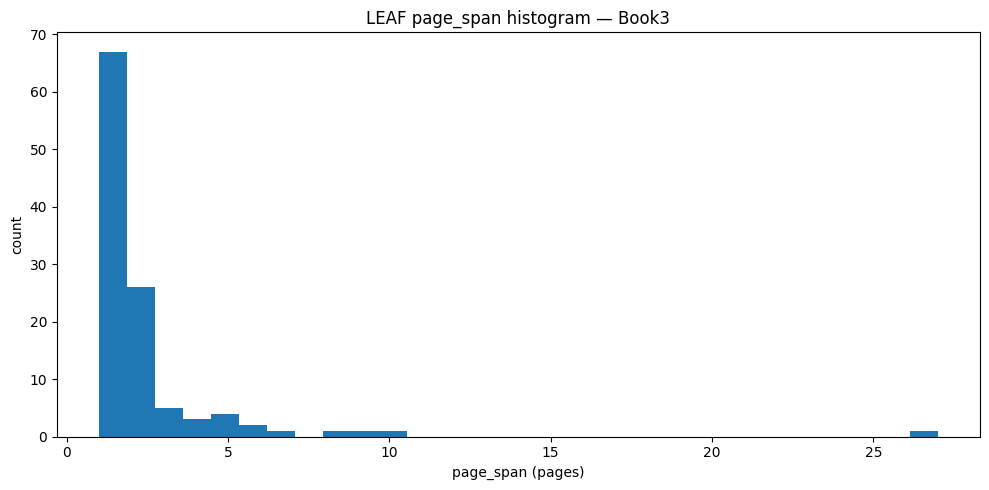

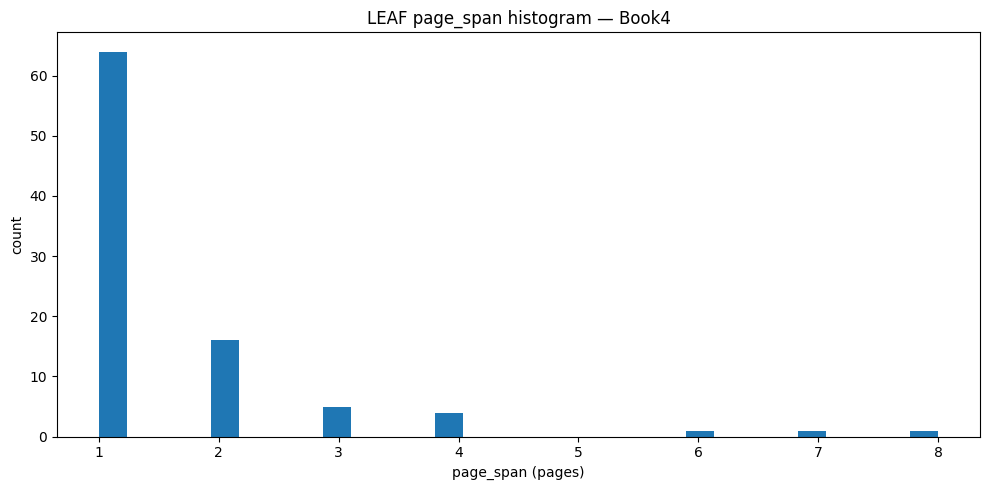

,book,n_leaf,pct_leaf_span_gt_5,avg_leaf_span,max_leaf_span
0,Book1,47,0.063830,1.765957,8.0
1,Book2,93,0.043011,2.064516,8.0
2,Book3,112,0.062500,2.133929,27.0
3,Book4,92,0.032609,1.608696,8.0


In [8]:
# CELL 7 — STEP 6: Section span analysis (pages) for LEAF nodes + plot + %>5 pages

df_leaf = df_sections_all[df_sections_all["is_leaf"]].copy()
df_leaf["page_span"] = (df_leaf["end_page"].fillna(df_leaf["start_page"]) - df_leaf["start_page"] + 1).astype(float)
df_leaf.loc[df_leaf["page_span"] < 0, "page_span"] = np.nan

# Histogram of page_span per book (leaf only)
for b, g in df_leaf.groupby("book"):
    span = g["page_span"].dropna().astype(float)
    if span.empty:
        continue
    plt.figure()
    plt.hist(span, bins=30)
    plt.title(f"LEAF page_span histogram — {b}")
    plt.xlabel("page_span (pages)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# % leaf sections with span > 5 pages per book
span_rows = []
for b, g in df_leaf.groupby("book"):
    span = g["page_span"].dropna().astype(float)
    span_rows.append({
        "book": b,
        "n_leaf": int(len(g)),
        "pct_leaf_span_gt_5": float((span > 5).mean()) if len(span) else float("nan"),
        "avg_leaf_span": float(span.mean()) if len(span) else float("nan"),
        "max_leaf_span": float(span.max()) if len(span) else float("nan"),
    })
df_span = pd.DataFrame(span_rows).sort_values("book")
display(df_span)

In [9]:
# CELL 8 — STEP 7: Structural outliers (LEAF nodes only) + Save

def topn(df: pd.DataFrame, sort_col: str, n: int = 5) -> pd.DataFrame:
    cols = ["book","section_id","title","level","token_count","word_count","table_count","figure_count","start_page","end_page","node_id","parent_node_id"]
    out = (df.sort_values(sort_col, ascending=False)
             .head(n)[cols].reset_index(drop=True))
    return out

outlier_frames = []
for b, g in df_leaf.groupby("book"):
    g = g.copy()
    # top 5 longest by tokens
    t_long = topn(g, "token_count", 5)
    t_long["outlier_type"] = "top5_longest_tokens"
    # top 5 highest tables
    t_tab = topn(g, "table_count", 5)
    t_tab["outlier_type"] = "top5_tables"
    # top 5 deepest nodes (level desc, tie token_count desc)
    g2 = g.sort_values(["level","token_count"], ascending=[False, False])
    t_deep = g2.head(5)[["book","section_id","title","level","token_count","word_count","table_count","figure_count","start_page","end_page","node_id","parent_node_id"]].reset_index(drop=True)
    t_deep["outlier_type"] = "top5_deepest_level_then_tokens"
    outlier_frames.extend([t_long, t_tab, t_deep])

df_outliers = pd.concat(outlier_frames, ignore_index=True) if outlier_frames else pd.DataFrame()
display(df_outliers.head(30))

df_outliers.to_csv(OUT_SUMMARY_DIR / "outliers_per_book.csv", index=False)
print("Saved:", OUT_SUMMARY_DIR / "outliers_per_book.csv")

# Save leaf sections across all books
df_leaf_out = df_leaf.copy()
df_leaf_out.to_csv(OUT_SUMMARY_DIR / "leaf_sections_all_books.csv", index=False)
print("Saved:", OUT_SUMMARY_DIR / "leaf_sections_all_books.csv")

,book,section_id,title,level,token_count,word_count,table_count,figure_count,start_page,end_page,node_id,parent_node_id,outlier_type
0,Book1,3,Definitions,2,1826,1830,0,0,15,22,T8:3,T1:Part I,top5_longest_tokens
1,Book1,B1,Data Elements by Name,3,1222,1256,1,0,67,72,T57:B1,T56:Annex B,top5_longest_tokens
2,Book1,12.4,Final Selection,3,841,837,0,0,61,63,T52:12.4,T41:12,top5_longest_tokens
3,Book1,12.3.2,Using the PSE,4,833,842,0,1,55,57,T50:12.3.2,T48:12.3,top5_longest_tokens
4,Book1,12.3.3,Using a List of AIDs,4,814,805,0,1,58,60,T51:12.3.3,T48:12.3,top5_longest_tokens
5,Book1,11.3.4,Data Field Returned in the Response Message,4,429,433,5,0,44,46,T39:11.3.4,T35:11.3,top5_tables
6,Book1,11.3.2,Command Message,4,117,118,3,0,43,44,T37:11.3.2,T35:11.3,top5_tables
7,Book1,12.2.3,Coding of a Payment System Directory,4,434,441,3,0,51,52,T46:12.2.3,T43:12.2,top5_tables
8,Book1,11.2.3,Data Field Sent in the Command Message,4,10,10,2,0,42,42,T32:11.2.3,T29:11.2,top5_tables
9,Book1,11.2.2,Command Message,4,83,83,2,0,42,42,T31:11.2.2,T29:11.2,top5_tables


Saved: ../../data/summary/outliers_per_book.csv
Saved: ../../data/summary/leaf_sections_all_books.csv


In [10]:
# CELL 9 — STEP 8: Cross-book homogeneity comparison table + STEP 9: Chunking recommendations

# Helper: avg leaf tokens at level==3
def avg_leaf_level_tokens(df_leaf: pd.DataFrame, level: int) -> pd.Series:
    return (df_leaf[df_leaf["level"] == level]
            .groupby("book")["token_count"]
            .mean())

# Compute required metrics
book_meta = df_books.set_index("book")

leaf_tokens = df_leaf.groupby("book")["token_count"].agg(["mean", lambda x: float((x > 1000).mean()) if len(x) else float("nan")])
leaf_tokens.columns = ["avg_leaf_tokens", "pct_leaf_gt_1000"]

leaf_tables = df_leaf.groupby("book")["table_count"].sum().rename("total_leaf_tables")

lvl3_avg_leaf_tokens = avg_leaf_level_tokens(df_leaf, 3).rename("avg_leaf_level3_tokens")

df_compare = pd.DataFrame(index=sorted(df_sections_all["book"].unique()))
df_compare["max_depth"] = book_meta["max_depth"]
df_compare["avg_depth"] = book_meta["avg_depth"]
df_compare["avg_leaf_tokens"] = leaf_tokens["avg_leaf_tokens"]
df_compare["pct_leaf_gt_1000"] = leaf_tokens["pct_leaf_gt_1000"]
df_compare["total_leaf_tables"] = leaf_tables
df_compare["avg_leaf_level3_tokens"] = lvl3_avg_leaf_tokens

df_compare = df_compare.reset_index().rename(columns={"index":"book"})
display(df_compare)

# Pivot to Metric | Book1 | Book2 ...
df_comp_pivot = df_compare.set_index("book").T.reset_index().rename(columns={"index":"Metric"})
display(df_comp_pivot)

# Chunking strategy decision framework (programmatic)
def chunking_recommendation_for_book(book: str, df_all: pd.DataFrame, df_leaf: pd.DataFrame, max_depth: float, pct_leaf_gt_1000: float) -> str:
    recs = []
    if pd.isna(pct_leaf_gt_1000): pct_leaf_gt_1000 = 0.0
    if pd.isna(max_depth): max_depth = 0

    if pct_leaf_gt_1000 <= 0.15 and max_depth >= 3:
        recs.append("Structure-based chunking at deepest stable level")
    elif 0.15 < pct_leaf_gt_1000 <= 0.40:
        recs.append("Hybrid: structural + token splitting for large sections")
    else:
        recs.append("Aggressive splitting: many oversized leaf sections")

    # table-aware chunking
    leaf_b = df_leaf[df_leaf["book"] == book]
    n_leaf = len(leaf_b)
    total_tables = float(leaf_b["table_count"].sum()) if n_leaf else 0.0
    tables_per_leaf = (total_tables / n_leaf) if n_leaf else 0.0
    if tables_per_leaf > 0.25:
        recs.append("Table-aware chunking")

    # level2 vs level3 avg tokens ratio
    b_all = df_all[df_all["book"] == book]
    lvl2 = b_all[b_all["level"] == 2]["token_count"].dropna().astype(float)
    lvl3 = b_all[b_all["level"] == 3]["token_count"].dropna().astype(float)
    avg2 = float(lvl2.mean()) if len(lvl2) else float("nan")
    avg3 = float(lvl3.mean()) if len(lvl3) else float("nan")
    ratio = (avg2 / avg3) if (not pd.isna(avg2) and not pd.isna(avg3) and avg3 > 0) else float("nan")
    if not pd.isna(ratio) and ratio > 2.0:
        recs.append("Use level 3 as base chunk")

    return " | ".join(recs)

rec_rows = []
for _, r in df_books.iterrows():
    b = r["book"]
    md = r["max_depth"]
    pct_big = float(df_compare.set_index("book").loc[b, "pct_leaf_gt_1000"]) if b in set(df_compare["book"]) else 0.0
    rec_rows.append({
        "book": b,
        "recommendation": chunking_recommendation_for_book(b, df_sections_all, df_leaf, md, pct_big)
    })

df_recs = pd.DataFrame(rec_rows).sort_values("book")
display(df_recs)

df_recs.to_csv(OUT_SUMMARY_DIR / "chunking_recommendations.csv", index=False)
print("Saved:", OUT_SUMMARY_DIR / "chunking_recommendations.csv")

,book,max_depth,avg_depth,avg_leaf_tokens,pct_leaf_gt_1000,total_leaf_tables,avg_leaf_level3_tokens
0,Book1,4,3.074627,294.872340,0.042553,28,338.352941
1,Book2,4,3.152672,440.903226,0.086022,54,411.463415
2,Book3,4,3.119205,417.383929,0.089286,79,448.259259
3,Book4,4,3.142857,277.010870,0.043478,50,260.581395


book,Metric,Book1,Book2,Book3,Book4
0,max_depth,4.000000,4.000000,4.000000,4.000000
1,avg_depth,3.074627,3.152672,3.119205,3.142857
2,avg_leaf_tokens,294.872340,440.903226,417.383929,277.010870
3,pct_leaf_gt_1000,0.042553,0.086022,0.089286,0.043478
4,total_leaf_tables,28.000000,54.000000,79.000000,50.000000
5,avg_leaf_level3_tokens,338.352941,411.463415,448.259259,260.581395


,book,recommendation
0,Book1,Structure-based chunking at deepest stable lev...
1,Book2,Structure-based chunking at deepest stable lev...
2,Book3,Structure-based chunking at deepest stable lev...
3,Book4,Structure-based chunking at deepest stable lev...


Saved: ../../data/summary/chunking_recommendations.csv


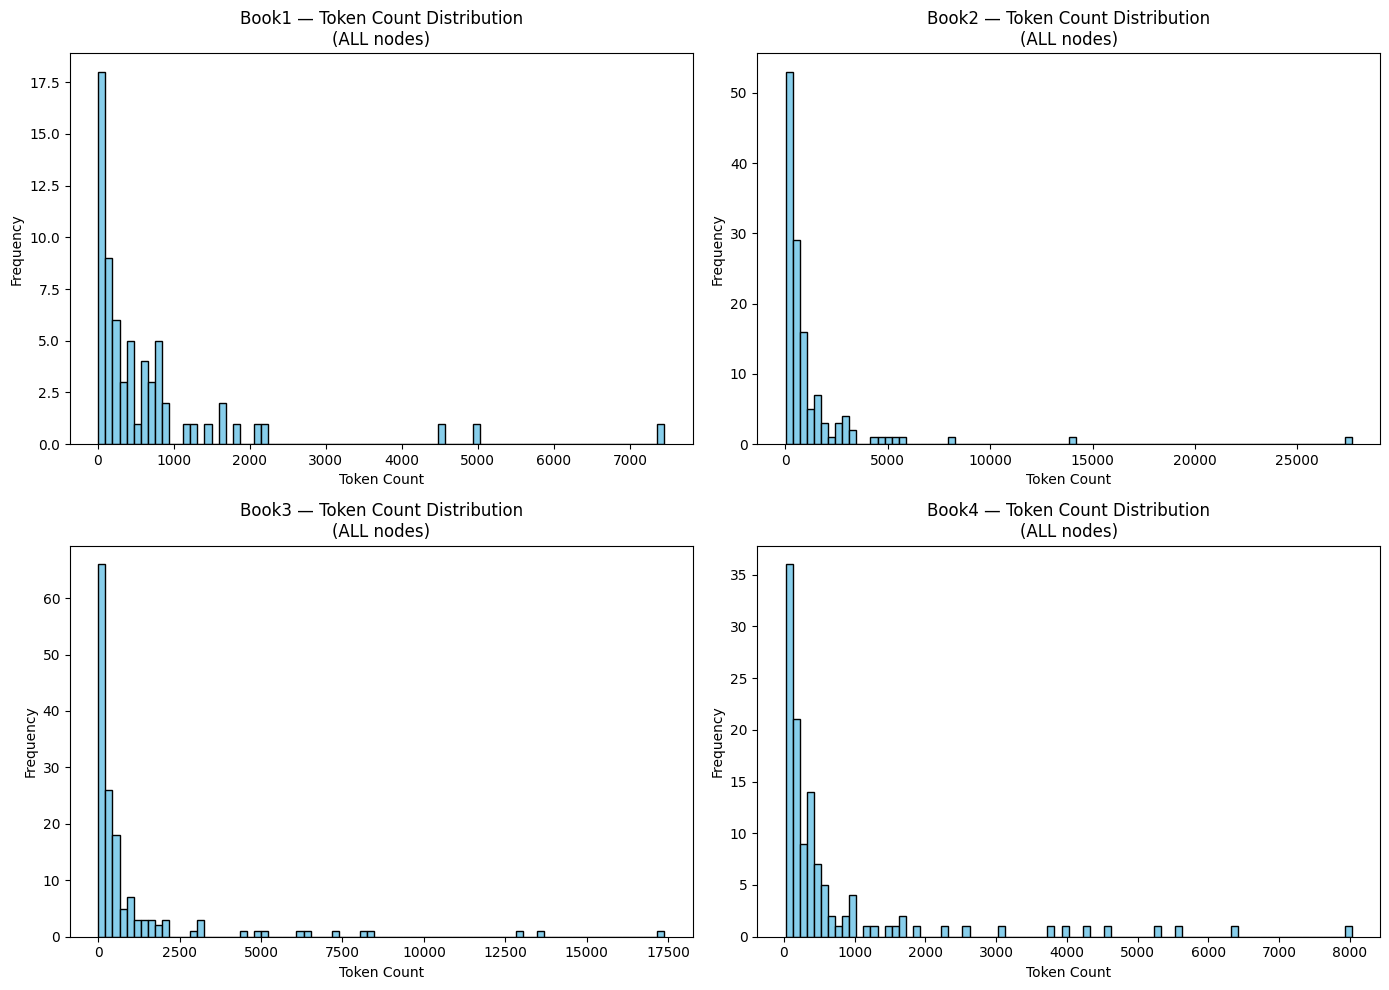

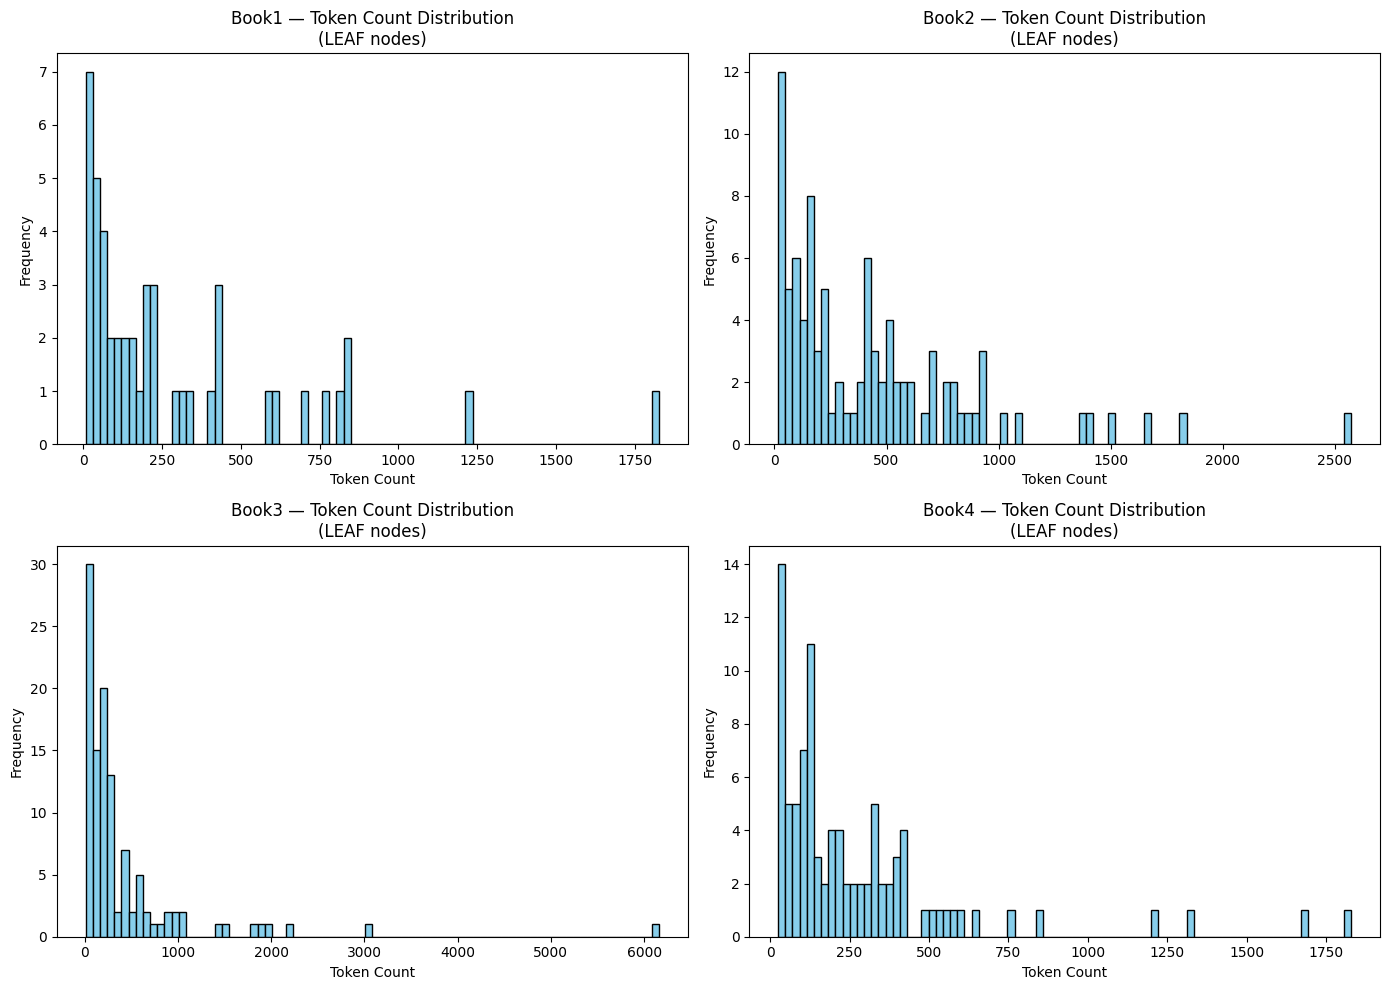

In [11]:
# Distribution of section lengths (tokens)
# Separate subplot per book (NOT overlapping in the same axes)

import math
import matplotlib.pyplot as plt

def plot_token_distribution_separate(df: pd.DataFrame, leaf_only: bool = False, bins: int = 80):
    d = df[df["is_leaf"]].copy() if leaf_only else df.copy()
    books = sorted(d["book"].unique())
    n = len(books)

    if n == 0:
        print("No books found.")
        return

    # 1. Set 2 columns and calculate necessary rows
    ncols = 2
    nrows = math.ceil(n / ncols)

    # 2. Adjust figsize: Width is larger for 2 columns (e.g., 14), height per row (e.g., 5)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows), sharex=False)

    # 3. Flatten axes to a 1D list for easy iteration
    # If n=1 and ncols=2, axes is already 1D. If nrows > 1, it is 2D.
    if n > 1 or ncols > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i, b in enumerate(books):
        ax = axes_flat[i]
        x = d.loc[d["book"] == b, "token_count"].dropna().astype(float)
        
        ax.hist(x, bins=bins, color='skyblue', edgecolor='black')
        ax.set_title(f"{b} — Token Count Distribution\n({'LEAF' if leaf_only else 'ALL'} nodes)")
        ax.set_xlabel("Token Count")
        ax.set_ylabel("Frequency")

    # 4. Hide empty subplots if the number of books is odd
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()
# All nodes
plot_token_distribution_separate(df_sections_all, leaf_only=False, bins=80)

# Leaf-only (recommended for chunking analysis)
plot_token_distribution_separate(df_sections_all, leaf_only=True, bins=80)

,book,pct_leaf_gt_1000
0,Book1,4.255319
1,Book2,8.602151
2,Book3,8.928571
3,Book4,4.347826


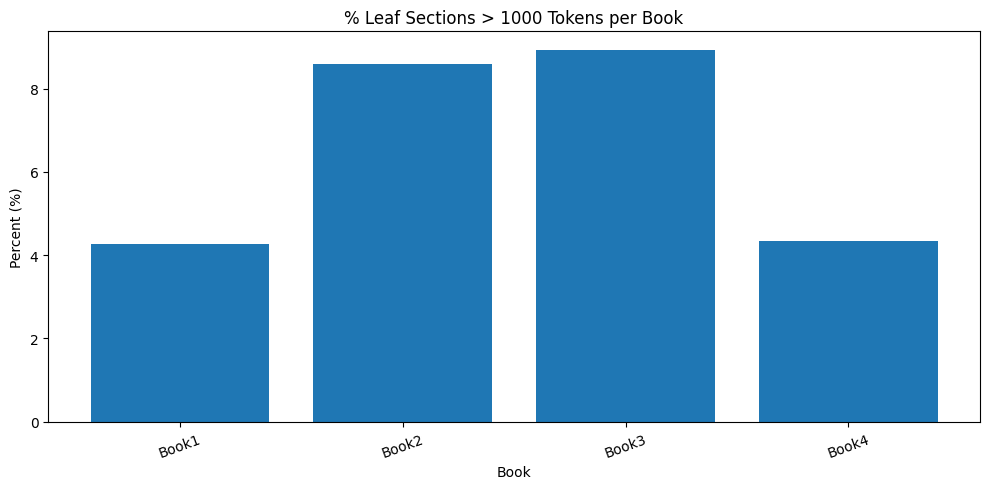

Saved: ../../data/summary/pct_leaf_gt_1000_per_book.csv


In [12]:
# 3️⃣ % Leaf Sections > 1000 Tokens per Book (bar plot)
# 4️⃣ Page Span Distribution (Leaf Nodes) (histograms)

# --- 3) % Leaf Sections > 1000 Tokens per Book ---
df_leaf = df_sections_all[df_sections_all["is_leaf"]].copy()
df_leaf["token_count"] = pd.to_numeric(df_leaf["token_count"], errors="coerce").fillna(0).astype(float)

pct_large = (
    df_leaf.groupby("book")["token_count"]
    .apply(lambda x: float((x > 1000).mean()) if len(x) else float("nan"))
    .reset_index(name="pct_leaf_gt_1000")
)
pct_large["pct_leaf_gt_1000"] = pct_large["pct_leaf_gt_1000"] * 100.0
pct_large = pct_large.sort_values("book")

display(pct_large)

plt.figure(figsize=(10, 5))
plt.bar(pct_large["book"], pct_large["pct_leaf_gt_1000"])
plt.title("% Leaf Sections > 1000 Tokens per Book")
plt.xlabel("Book")
plt.ylabel("Percent (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Save if you want
pct_large.to_csv(OUT_SUMMARY_DIR / "pct_leaf_gt_1000_per_book.csv", index=False)
print("Saved:", OUT_SUMMARY_DIR / "pct_leaf_gt_1000_per_book.csv")



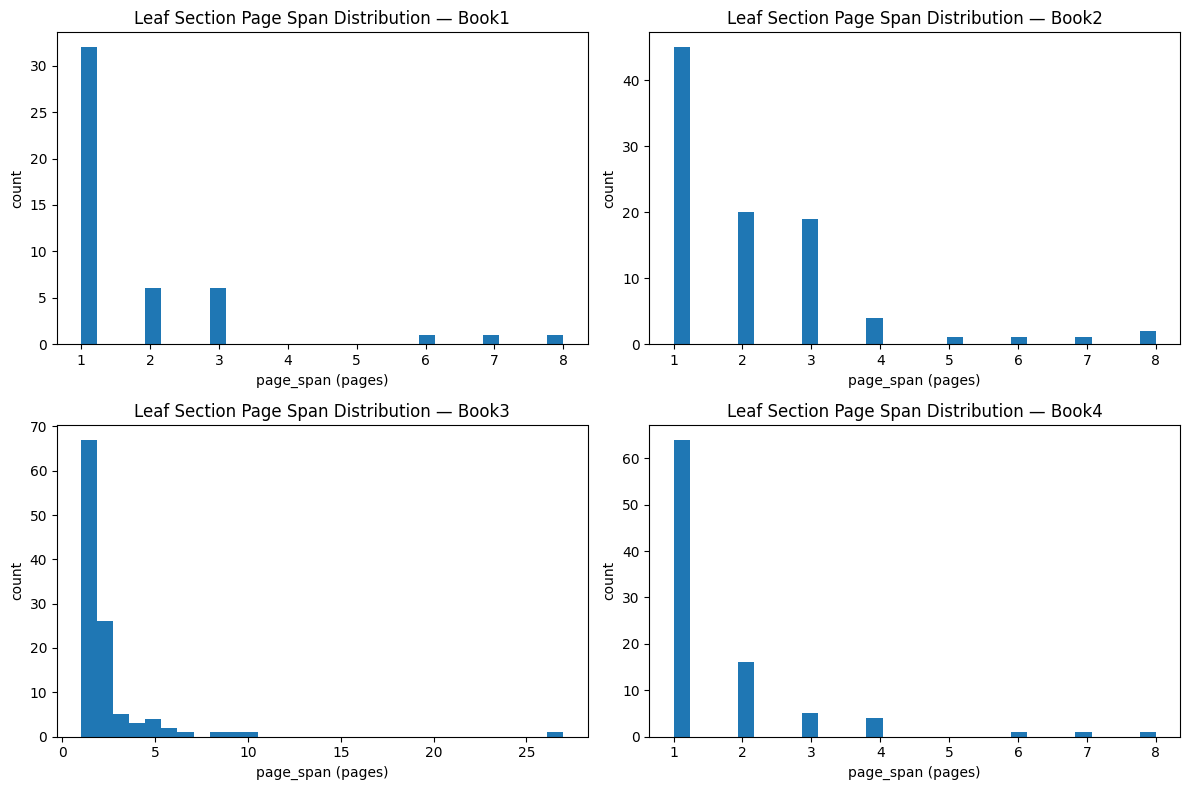

In [13]:
import math
import matplotlib.pyplot as plt
import numpy as np

# --- 4) Page Span Distribution (Leaf Nodes) ---
df_leaf["start_page"] = pd.to_numeric(df_leaf["start_page"], errors="coerce")
df_leaf["end_page"] = pd.to_numeric(df_leaf["end_page"], errors="coerce")
df_leaf["page_span"] = (df_leaf["end_page"] - df_leaf["start_page"] + 1).astype(float)
df_leaf.loc[df_leaf["page_span"] < 0, "page_span"] = np.nan

books = sorted(df_leaf["book"].unique())
n = len(books)

if n > 0:
    # Set to 2 columns and calculate rows
    ncols = 2
    nrows = math.ceil(n / ncols)
    
    # Create the figure with default settings
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    
    # Flatten axes to handle the 2D array
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]
    
    for i, b in enumerate(books):
        ax = axes_flat[i]
        span = df_leaf.loc[df_leaf["book"] == b, "page_span"].dropna().astype(float)
        
        # Default histogram (standard blue, no extra styling)
        ax.hist(span, bins=30)
        ax.set_title(f"Leaf Section Page Span Distribution — {b}")
        ax.set_xlabel("page_span (pages)")
        ax.set_ylabel("count")
        
    # Remove any empty subplots if n is odd
    for j in range(i + 1, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()

# Save summary
df_leaf[["book","node_id","section_id","title","start_page","end_page","page_span","token_count"]].to_csv(
    OUT_SUMMARY_DIR / "leaf_page_spans.csv", index=False
)